Библиотеки успешно импортированы.
Набор данных успешно загружен.
   age         workclass  fnlwgt  education  education_num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital_status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital_gain  capital_loss  hours_per_week native_country income  
0          2174             0              40  

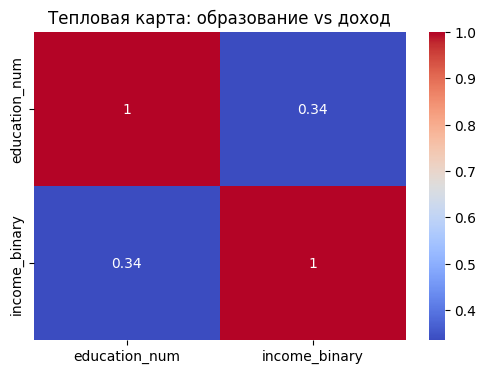

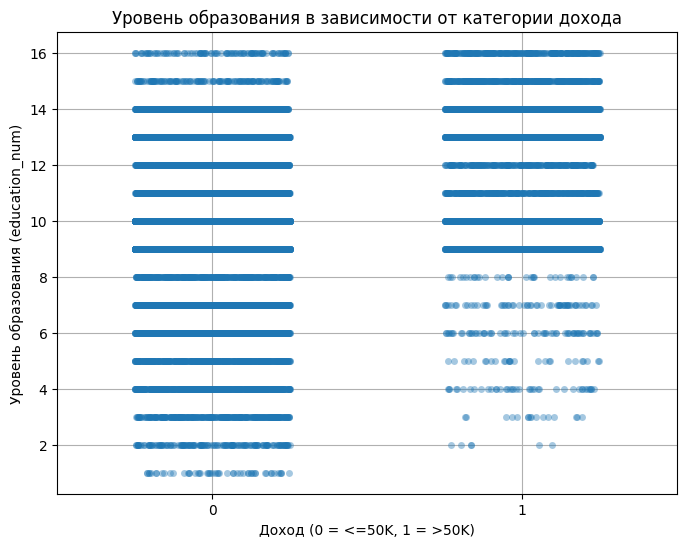

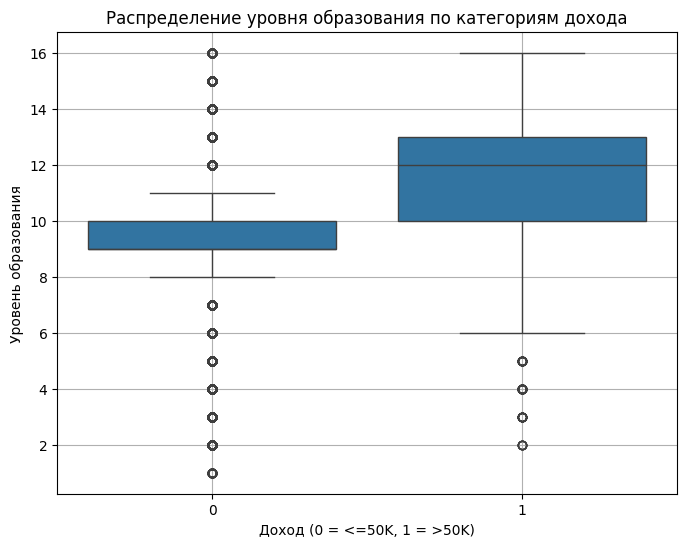

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

print("Библиотеки успешно импортированы.")


# 1. Загрузка набора данных Adult Income


url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

df = pd.read_csv(url, header=None, names=columns, na_values=" ?", skipinitialspace=True)

print("Набор данных успешно загружен.")
print(df.head())


# 2. Очистка данных

print("\nПропущенные значения до очистки:")
print(df.isnull().sum())

df.dropna(inplace=True)

print("\nПропущенные значения после очистки:")
print(df.isnull().sum())


# 3. Фокус анализа: образование и доход


# Преобразуем доход в бинарный формат (<=50K = 0, >50K = 1)
df["income_binary"] = df["income"].apply(lambda x: 1 if x == ">50K" else 0)

print("\nПример данных по образованию и доходу:")
print(df[["education", "education_num", "income", "income_binary"]].head())


# 4. Расчёт корреляции

corr_value = df["education_num"].corr(df["income_binary"], method="pearson")

print("\n============================================")
print("Корреляция между уровнем образования и доходом:")
print(f"Коэффициент Пирсона = {corr_value:.4f}")
print("============================================")


# 5. Тепловая карта корреляции

plt.figure(figsize=(6, 4))
sns.heatmap(df[["education_num", "income_binary"]].corr(), annot=True, cmap="coolwarm")
plt.title("Тепловая карта: образование vs доход")
plt.show()


# 6. График рассеяния (stripplot)


plt.figure(figsize=(8, 6))
sns.stripplot(x=df["income_binary"], y=df["education_num"], alpha=0.4, jitter=0.25)
plt.title("Уровень образования в зависимости от категории дохода")
plt.xlabel("Доход (0 = <=50K, 1 = >50K)")
plt.ylabel("Уровень образования (education_num)")
plt.grid(True)
plt.show()


# 7. Boxplot для лучшей визуализации


plt.figure(figsize=(8, 6))
sns.boxplot(x=df["income_binary"], y=df["education_num"])
plt.title("Распределение уровня образования по категориям дохода")
plt.xlabel("Доход (0 = <=50K, 1 = >50K)")
plt.ylabel("Уровень образования")
plt.grid(True)
plt.show()